In [1]:
import cv2
from ultralytics import YOLO
import matplotlib.pyplot as plt

import os
import sys

import sklearn.metrics as metrics

parent = os.path.abspath("..")
if parent not in sys.path:
    sys.path.append(parent)

from src.config import settings

In [2]:
best_model: YOLO = YOLO(
    model="../models/runs/translation/train6-yolo/weights/best.pt",
    task="classify",
)

best_model.info()

YOLO11n-cls summary: 86 layers, 1,564,410 parameters, 0 gradients, 3.3 GFLOPs


(86, 1564410, 0, 3.2789504)

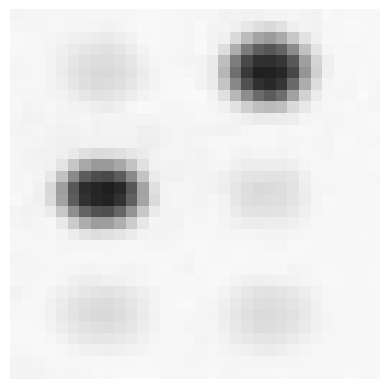

In [3]:
img = cv2.imread("../data/processed/kaggle/yolo/test/i/i1.JPG0dim_aug_0_blur.jpg")
plt.imshow(img)
plt.axis("off")
plt.show()

In [4]:
predictions = best_model.predict(img, conf=0.7)
prediction = predictions[0]
probs = prediction.probs

conf = probs.top1conf
cls = probs.top1
character = settings.CHARACTERS_LOWERCASE[cls]

print(f"Confidence: {conf}")
print(f"Class: {cls} -- {character}")


0: 32x32 i 0.99, e 0.01, h 0.00, f 0.00, j 0.00, 3.1ms
Speed: 68.5ms preprocess, 3.1ms inference, 0.0ms postprocess per image at shape (1, 3, 32, 32)
Confidence: 0.9932050704956055
Class: 8 -- i


In [19]:
# TODO: Find a way to implement exactly the top5 predictions! Awesome

display(probs.top5, probs.top5conf)
round(float(sum((i * conf for i, conf in zip(probs.top5, probs.top5conf)))))

[8, 4, 7, 5, 9]

tensor([9.9321e-01, 5.2495e-03, 5.5671e-04, 3.9824e-04, 2.8790e-04])

8

In [ ]:
from pathlib import Path


test_path = Path("../data/processed/kaggle/yolo/test")
test_set = list(test_path.rglob("*.jpg"))
y_true = [i.parent.name for i in test_set]
imgs = [cv2.imread(str(i), cv2.IMREAD_COLOR_BGR) for i in test_set]

predictions = best_model.predict(imgs, conf=0.7, stream=True)
y_pred = [settings.CHARACTERS_LOWERCASE[p.probs.top1] for p in predictions]

In [15]:
print(f"Accuracy: {metrics.accuracy_score(y_true, y_pred):.4%}")
print(f"F1 Score: {metrics.f1_score(y_true, y_pred, average='weighted'):.4%}")

Accuracy: 97.6211%
F1 Score: 97.6783%
